(mmm_learning_path)=

# Getting Started with Marketing Mix Modeling: A Guided Path

You want to know which of your marketing channels work. You found PyMC-Marketing, opened the {ref}`example gallery <gallery>`, and found more than forty MMM notebooks with no obvious entry point. This page is that entry point. It tells you what to read, what to run, and in which order.

```{note}
This page assumes that you can write basic Python and that you have seen a regression. It assumes that you know nothing about Bayesian statistics, causal inference, adstock, or saturation.

It is **not** for you if you already build MMMs and want the API. Use the {doc}`API reference </api/index>` instead. It is not for you if you are upgrading between versions. The migration guides are maintenance documents and are deliberately excluded from this path.
```

## Before anything else: can your data support an MMM?

Most failed marketing mix models fail before the first line of code. If you skip this section, you can spend three weeks to produce a number that nobody can believe. Check these four things against your own dataset now.

**1. Do you have enough history?** Two years of weekly data is about 104 rows. That is already small for the question you ask. Below about 18 months you will struggle to separate advertising from seasonality, because you have seen each season only once. The model will not refuse to run. It will run, and it will give you confident answers that are wrong.

**2. Did your spend actually vary?** The model learns about a channel from the times you spent differently on it. A channel funded at a flat €50k every week for two years contains almost no information about what happens at €30k or €80k. If your media plan was stable, the model will largely return your priors to you. That is not a bug, but you need to know that it happens.

**3. How many channels do you ask about?** Each channel costs several parameters: carryover, saturation, and effect size. Twelve channels against 104 weeks is a hard estimation problem. Group small or highly correlated channels before you model ("paid social" instead of four platforms). Split them later, and only when a split changes a decision.

**4. Are your channels correlated with each other?** If TV and search budgets always rise together in the fourth quarter, the model cannot easily tell their effects apart. Look at a correlation matrix of your spend columns before you model. High correlation does not disqualify your data, but it tells you which estimates will be uncertain and where you will need an experiment.

**If you fail two or more of these checks**, the most valuable action is not to build a model. It is to run a lift test, or to deliberately vary spend for a quarter so that next year's data can answer the question. To return with an experiment is faster than to model your way out of a problem that the data cannot identify.

These are rules of thumb, not thresholds with theory behind them. Their purpose is to make you look at your data before you look at the API.

## How the path is labelled

Each entry carries two labels, because "difficulty" alone hides what you need to know.

**What it demands of you**

| Label | Meaning |
|---|---|
| `concepts` | New statistical ideas. Slow reading, no special background. |
| `compute` | Conceptually simple, but slow or fragile to sample. Budget patience, not brainpower. |
| `internals` | Requires you to write PyMC models directly, not only to configure PyMC-Marketing. |

A geo-hierarchical model is `compute`, not hard to understand. A custom {class}`MuEffect <pymc_marketing.mmm.additive_effect.MuEffect>` is `internals`, not statistically deep. Causal identification is `concepts` and needs no code at all. To merge these three into one "advanced" label is the reason why that label is useless.

**What to do with it**

| Mode | Meaning |
|---|---|
| **Run** | Execute the cells, change something, run again. Learning happens in the difference. |
| **Read** | An article that happens to contain code. To read it is enough. |
| **Reference** | Do not read it from start to end. Return to it when you have the specific problem. |

This page gives no runtime estimates. Hand-written estimates go stale within a release and are worse than nothing.

## Stage 0: the ideas you need before any code

**Read this. It takes about half an hour. It is the vocabulary that the rest of the documentation assumes you already have.** For a longer conceptual introduction, see {doc}`/guide/mmm/mmm_intro`.

### Part A: why an MMM is harder than a regression

You have weekly sales and weekly spend per channel. You want a decomposition: how much revenue each channel caused, and what happens if you move money between channels. Three things stop this from being an ordinary regression.

**Advertising has memory.** Someone sees your ad on Monday and buys on Friday. This week's sales depend on several previous weeks of spend, and the effect decays over time. That decay is **adstock**, also called carryover.

**Advertising has diminishing returns.** The tenth impression on the same person is worth less than the first. To double the spend does not double the effect. That curvature is **saturation**. It is the reason why the answer to "should I spend more here?" depends entirely on how much you already spend.

**You did not run an experiment.** You spent more in December. You also sold more in December. Was that advertising, or Christmas? This is **confounding**. It is the reason why a model with excellent fit statistics can still be completely wrong about causation. Carry this sentence with you: *to predict sales well and to estimate causal effects correctly are different achievements, and the first does not imply the second.*

**What an MMM cannot do.** It cannot attribute individual conversions. It cannot say anything trustworthy about a channel whose spend never moved. It cannot produce a causal answer from observational data alone, without experiments or explicit, arguable assumptions.

The next cells draw the first two ideas. They use the same functions that the {class}`MMM <pymc_marketing.mmm.mmm.MMM>` class applies to your spend columns internally: {func}`geometric_adstock <pymc_marketing.mmm.transformers.geometric_adstock>` and {func}`logistic_saturation <pymc_marketing.mmm.transformers.logistic_saturation>`.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pytensor.xtensor as ptx

from pymc_marketing.mmm import LogisticSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

In [2]:
seed = sum(map(ord, "mmm"))
rng = np.random.default_rng(seed=seed)

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79151/775944440.py:31: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


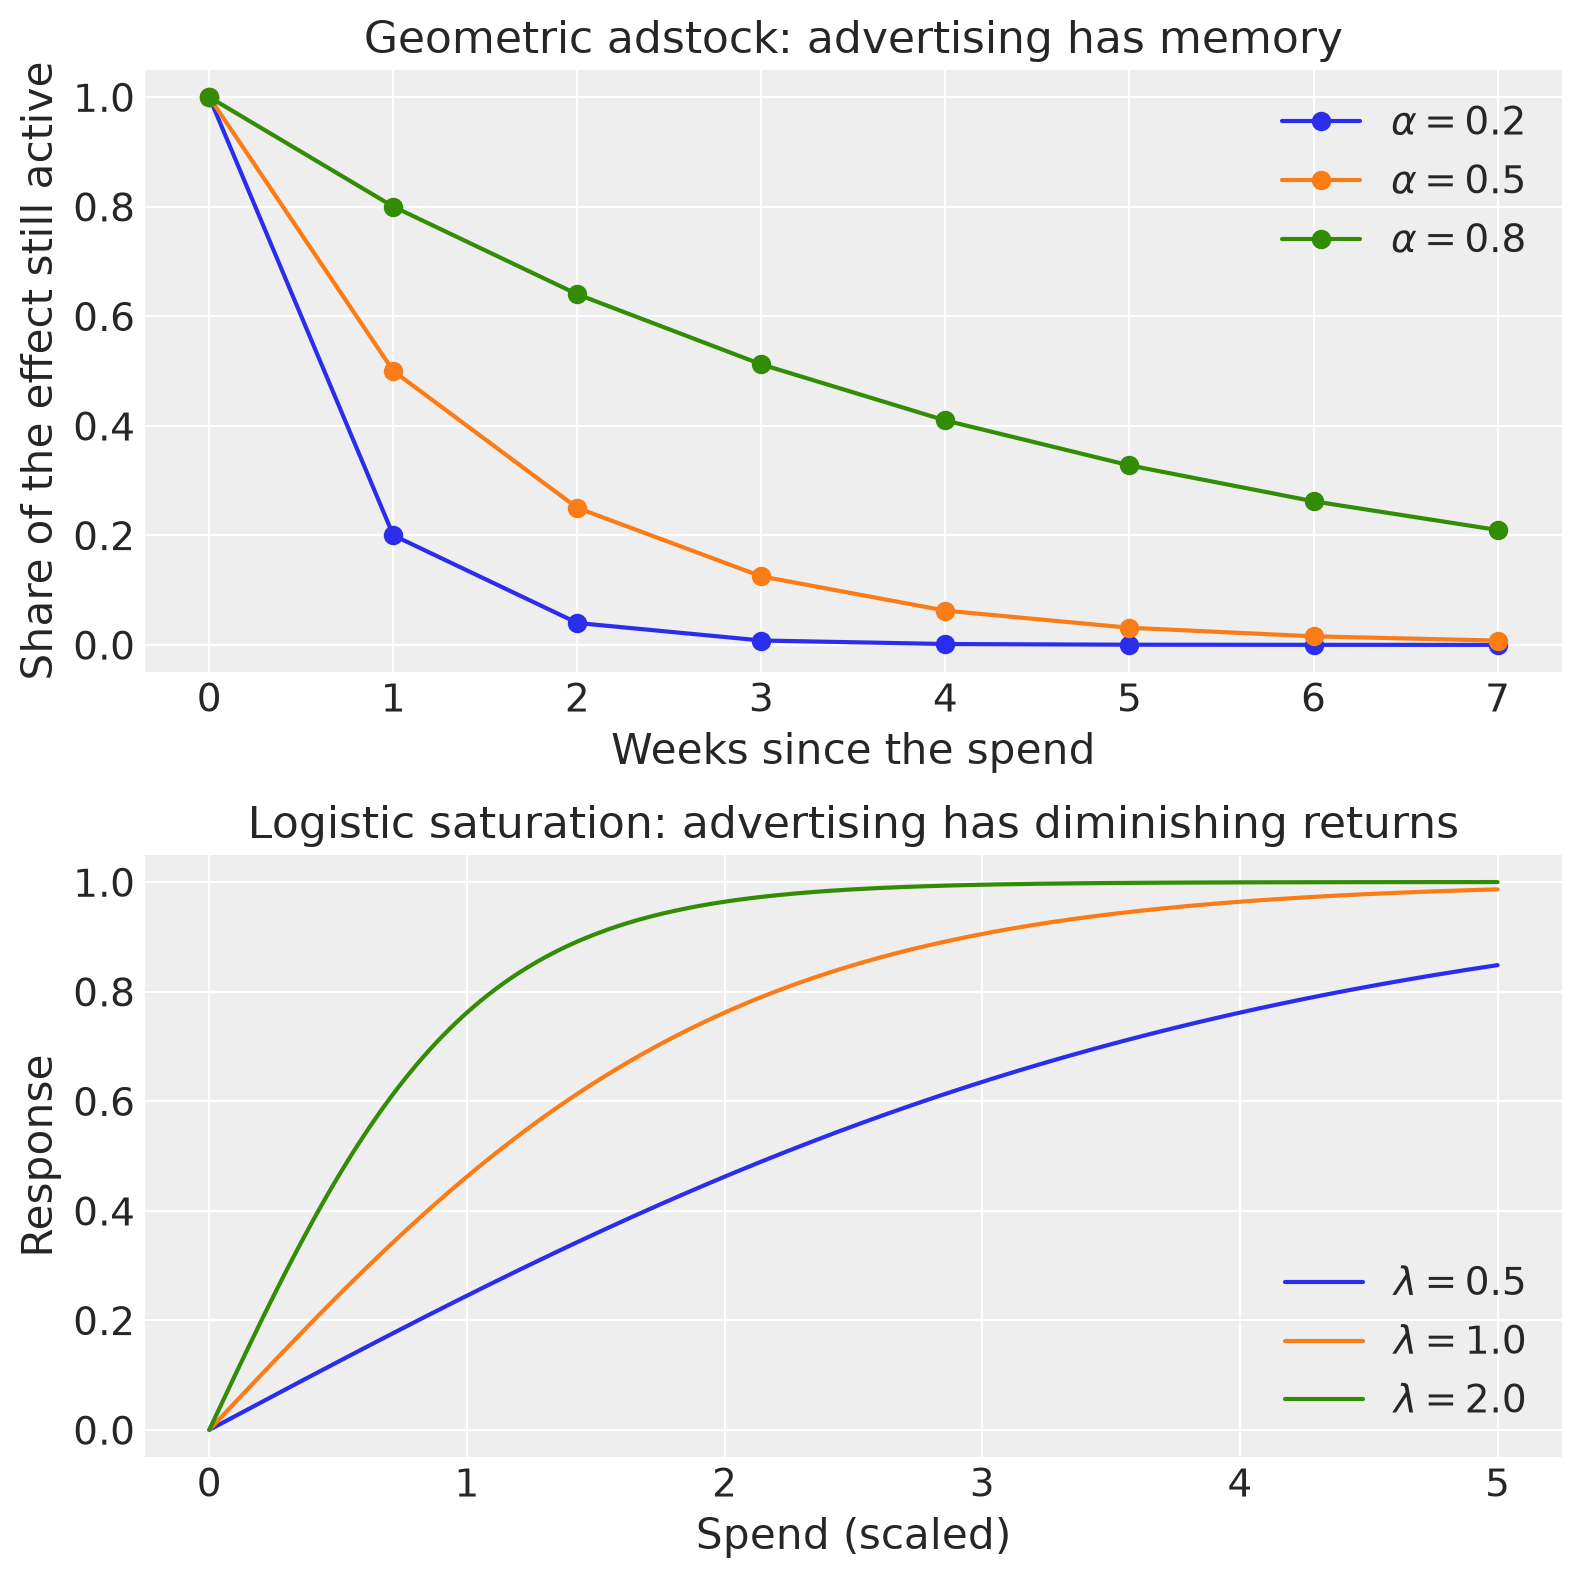

In [3]:
fig, (ax_adstock, ax_saturation) = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))

# Adstock: one unit of spend in week 0 and nothing afterwards.
l_max = 8
impulse = np.zeros(l_max)
impulse[0] = 1.0
weeks = np.arange(l_max)
for alpha in (0.2, 0.5, 0.8):
    effect = geometric_adstock(
        ptx.as_xtensor(impulse, dims=("time",)), alpha=alpha, l_max=l_max, dim="time"
    ).eval()
    ax_adstock.plot(weeks, effect, marker="o", label=rf"$\alpha = {alpha}$")
ax_adstock.set(
    xlabel="Weeks since the spend",
    ylabel="Share of the effect still active",
    title="Geometric adstock: advertising has memory",
)
ax_adstock.legend()

# Saturation: the response to increasing spend flattens out.
spend = np.linspace(0, 5, 200)
for lam in (0.5, 1.0, 2.0):
    response = logistic_saturation(ptx.as_xtensor(spend, dims=("x",)), lam=lam).eval()
    ax_saturation.plot(spend, response, label=rf"$\lambda = {lam}$")
ax_saturation.set(
    xlabel="Spend (scaled)",
    ylabel="Response",
    title="Logistic saturation: advertising has diminishing returns",
)
ax_saturation.legend()
fig.tight_layout();

The top panel shows what happens to one unit of spend in week zero. With $\alpha = 0.2$ the effect is nearly gone after two weeks. With $\alpha = 0.8$ about a fifth of it is still active seven weeks later. The parameter $\alpha$ is the memory of the channel.

The bottom panel shows how the response to spend flattens. With $\lambda = 2$ the curve reaches most of its maximum before one unit of spend, so extra money buys little. With $\lambda = 0.5$ there is still room to grow. The parameter $\lambda$ controls how fast a channel saturates.

An MMM does not know $\alpha$ and $\lambda$. It estimates them, for every channel, from your data. These two curves are the whole story of {ref}`Guide to Adstock Transformations <adstock_functions_guide>` and {ref}`Understanding Media Saturation <mmm_media_saturation>`. Do not study them yet. Stage 1 tells you when.

### Part B: what Bayesian modeling is, and why MMMs need it

PyMC-Marketing is built on [PyMC](https://www.pymc.io/), a Bayesian modeling library. If that word means nothing to you yet, this section is the minimum you need. You do not have to become a statistician to use this library, but you do need these four ideas. For the short version of the business case, see {doc}`/guide/benefits/why_bayesian`.

#### The core idea: parameters are ranges, not numbers

An ordinary regression gives you one number per coefficient. "Search ROAS is 2.3." That number is a best guess, and to treat it as a fact is where many bad marketing decisions come from.

Bayesian modeling instead gives you a **distribution** over each parameter. It is a statement of the form "ROAS is most likely around 2.3, quite plausibly between 1.4 and 3.6, and almost certainly not above 5." Everything downstream inherits that shape. When you ask the optimizer where to put next quarter's budget, it can answer with a range of outcomes instead of a single figure that happens to be wrong.

#### How you get there: prior, likelihood, posterior

Three pieces, and every Bayesian model is made of them.

**The prior** is what you believed before you saw this dataset, written as a distribution. For an MMM this is rarely difficult, because you do know things: advertising cannot have a negative effect on sales; carryover cannot last two years; ROAS on an established channel is in the low single digits, not forty. To encode those beliefs is not cheating. To refuse to encode them means to pretend that you know nothing, which is both false and unhelpful when you have a hundred rows of data.

**The likelihood** is your model of how the data was generated. In an MMM it is sales as a function of adstocked, saturated spend plus baseline, seasonality, and controls.

**The posterior** is what you believe after you combine the two. It is the output you actually work with. Where the data is informative, the posterior is driven by the data and the prior barely matters. Where the data is weak, for example a channel whose spend never varied, the posterior stays close to the prior. That is the model telling you honestly that this dataset had little to say.

Here is the prior made concrete for one transformation. The next cell prints the default priors of {class}`LogisticSaturation <pymc_marketing.mmm.components.saturation.LogisticSaturation>`: one distribution for the shape parameter $\lambda$ you saw above, and one for the effect size $\beta$.

In [4]:
saturation = LogisticSaturation()
saturation.default_priors

{'lam': Prior("Gamma", alpha=3, beta=1), 'beta': Prior("HalfNormal", sigma=2)}

Sampling: [saturation_beta, saturation_lam]


Sampling: []


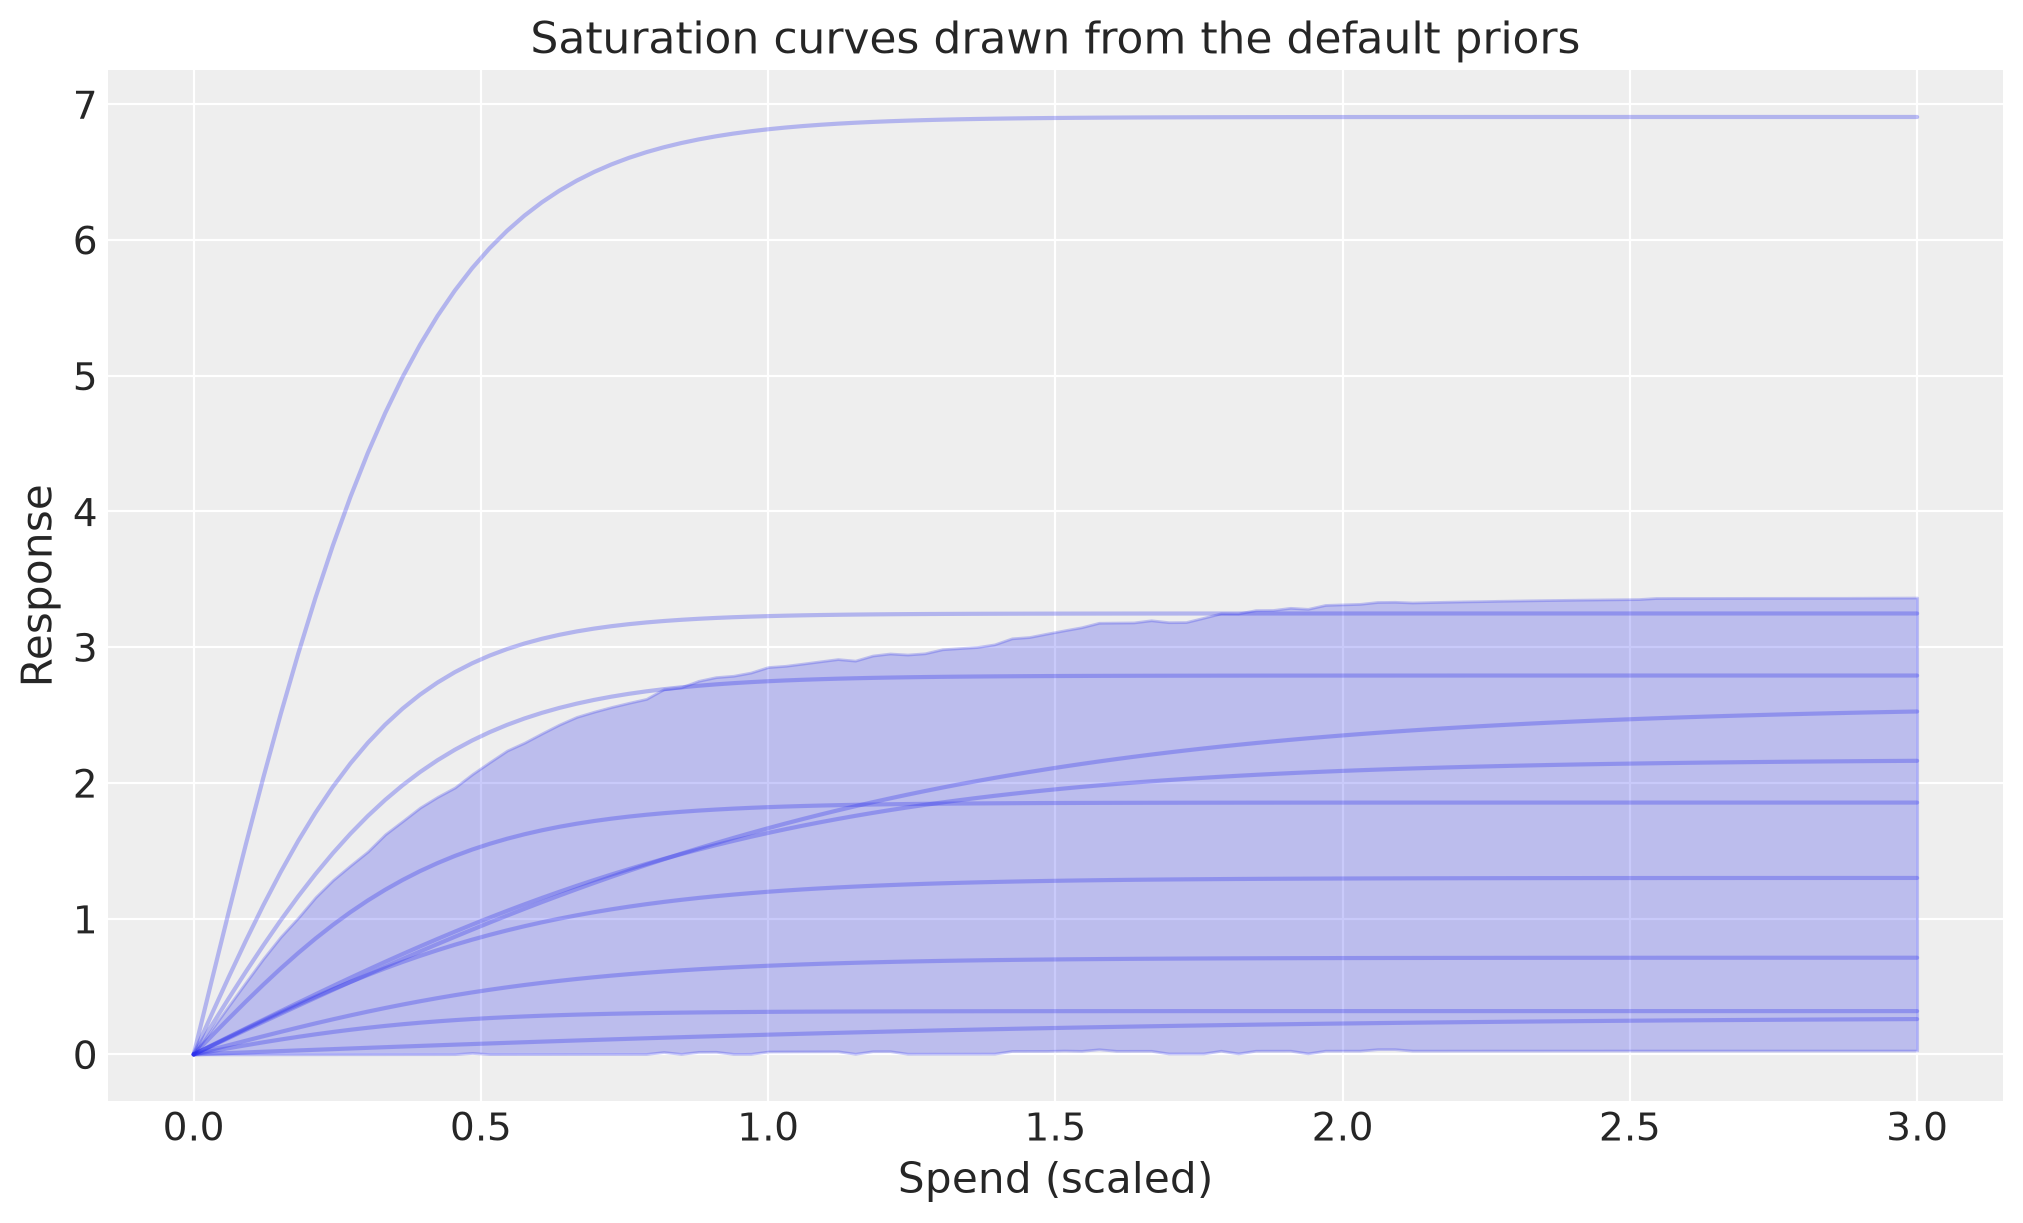

In [5]:
prior = saturation.sample_prior(random_seed=rng)
curve = saturation.sample_curve(prior, max_value=3, progressbar=False)
fig, axes = saturation.plot_curve(
    curve, random_seed=rng, subplot_kwargs={"figsize": (10, 6)}
)
axes[0].set(
    xlabel="Spend (scaled)",
    ylabel="Response",
    title="Saturation curves drawn from the default priors",
);

Before it sees any data, the model does not hold one saturation curve. It holds a whole family of plausible curves, and the shaded band shows how wide that family is. Data narrows the family. The narrowed family is the posterior. To simulate from your priors before you fit, and to check that the simulated businesses look plausible, is the habit that {ref}`Prior Predictive Checks <prior_predictive>` teaches.

#### How the answer is computed: sampling

The posterior usually has no closed-form expression, so PyMC approximates it. It draws thousands of samples from the posterior with **MCMC** (Markov chain Monte Carlo), specifically an algorithm called NUTS. This is why a fit takes minutes instead of milliseconds, and why your results object contains draws instead of a single fitted value.

It also means that a fit can fail in ways a regression cannot. You will see three terms in the output:

- **`r_hat`** tells you whether independent chains agreed with each other. It should be at or below 1.01. If it is higher, your chains explored different regions and the result is not trustworthy.
- **ESS (effective sample size)** tells you how many independent draws you effectively have. Low ESS on a parameter means that your estimate of *that parameter* is noisy, even if the rest of the model is fine.
- **Divergences** are the sampler hitting geometry it cannot navigate. A handful may be tolerable. Many mean that the results are suspect. They appear most often in hierarchical models, which is why the geo notebook is labelled `compute`.

When these go wrong, the fix is usually a reparameterization or better priors, not more samples.

#### Why this matters specifically for MMMs

Four reasons, in rough order of importance.

**1. Your data is small and your model is not.** A hundred or so weekly observations, and several parameters per channel. Classical estimation is unstable at that ratio. It will happily return an implausible carryover value because that value fits three noisy weeks slightly better. Priors act as a stabilizer: they keep parameters in ranges you can defend and let the data move them when the data has something to say.

**2. Uncertainty reaches the decision.** The point of an MMM is a budget recommendation. A Bayesian model propagates parameter uncertainty through the saturation curves and into the optimizer's output. You can ask "how likely is this reallocation to beat the current plan?" instead of "what is the single best plan if my estimates are exact?" Stage 3 is built around this.

**3. Experiments fit in naturally.** If you ran a lift test, you have a noisy measurement of one channel's true effect. In a Bayesian model that is one more piece of evidence, an extra likelihood term, combined with everything else in the usual way and with its own uncertainty respected. This is the calibration machinery in Stage 4, and it has no clean equivalent in a frequentist fitting procedure. In practice, it is the most valuable thing this library does.

**4. Hierarchy handles multiple regions gracefully.** With twelve countries you can fit twelve separate models (noisy, ignores shared structure) or one pooled model (ignores real differences). A Bayesian hierarchical model does neither. It estimates country-level effects that are pulled toward a shared mean, and the pull is proportional to how little data each country has. Small markets borrow strength from large ones automatically. This is **partial pooling**, and it is what the multidimensional notebook is really about.

#### What it costs you

A fit takes minutes to hours instead of seconds. You must check convergence instead of trusting the output. And priors are a modeling choice that you will be asked to defend. That is a feature, because the alternative is to make the same choices implicitly and never discuss them. But it does mean that more of the model is your responsibility.

#### Where to learn the underlying statistics

This page does not teach Bayesian modeling. If you want to go deeper, in increasing order of commitment:

- **[The PyMC example gallery](https://www.pymc.io/projects/examples/en/latest/gallery.html)** has worked notebooks across the whole method. The generalized linear model examples are the closest starting point to the structure of an MMM, and [A Primer on Bayesian Methods for Multilevel Modeling](https://www.pymc.io/projects/examples/en/latest/case_studies/multilevel_modeling.html) is worth reading before you attempt a geo model.
- **[The PyMC learning resources](https://www.pymc.io/projects/docs/en/stable/learn.html)** are curated tutorials, books, and talks maintained by the PyMC team. The {doc}`PyMC-Marketing resources page </guide/mmm/resources>` collects talks and articles about MMMs specifically.
- **[The PyMC Discourse forum](https://discourse.pymc.io/)** is the main community channel. It is the right place for questions about Bayesian modeling or PyMC itself, as opposed to the marketing-specific APIs of PyMC-Marketing. If your sampler diverges and you cannot work out why, ask there. Search first: your question has often been answered.
- **Books.** *Statistical Rethinking* (McElreath) is the standard recommendation to build intuition, and *Bayesian Analysis with Python* (Martin) is the most direct route if you want to stay in Python throughout.

**You do not need any of these to start.** Stage 1 is designed to work on the four ideas above. Come back to this list when a specific thing confuses you. That is when it will stick.

## Stage 1: see the whole machine move once

**Goal: a fitted model on data where the truth is known, because it was simulated. You are not trying to be right yet.**

| Notebook | Demands | Mode |
|---|---|---|
| {ref}`MMM Quickstart <mmm_quickstart>` | none | **Run** |
| {ref}`Understanding Media Saturation <mmm_media_saturation>` | `concepts` | **Run** |
| {ref}`Guide to Adstock Transformations <adstock_functions_guide>` | `concepts` | **Read** |
| {ref}`Prior Predictive Checks <prior_predictive>` | `concepts` | **Run** |

**Why this order.** The quickstart comes first, so that the concepts have something to attach to. To read about saturation before you have seen a fitted curve is abstract in a way that does not stick. Saturation and adstock then open the two transformations that the quickstart treated as black boxes. Prior predictive checks come last, once you have seen priors specified and can see the point of simulating from them.

**On prior predictive checks specifically.** This is Part B made concrete, and it is the habit most worth forming early. Before you fit anything, you simulate datasets from your priors alone and ask whether they look like plausible businesses. If your priors imply weekly revenues of forty million when your company makes two, your priors are wrong and no amount of data will fully rescue them. Five minutes here save days later.

**The exercise that matters.** Run the quickstart unchanged. Then change exactly one thing, for example the `l_max` argument of {class}`GeometricAdstock <pymc_marketing.mmm.components.adstock.GeometricAdstock>` or the scale of one prior, and run it again. To watch which parts of the output move, and by how much, teaches you more than the next three notebooks will.

**Checkpoint.** Produce two contribution plots from the same synthetic data with different values of `l_max`, and write one sentence that explains the difference. If you cannot write that sentence, read the adstock guide again before you continue.

## Stage 2: get your own data in

**Goal: a model on real data, and an honest list of what you do not trust about it.**

**This stage has a documented gap.** There is currently no notebook that covers the move from raw marketing data to a model-ready dataframe, and this is where most people stall. You must make these decisions yourself, with no page to point at:

- **Aggregation.** Daily or weekly? Weekly is usual, but your aggregation must be consistent with your adstock lag. A maximum lag of 8 means something very different at daily and at weekly resolution.
- **Spend or impressions?** Impressions are closer to the causal mechanism. Spend is what stakeholders control and report. The {ref}`Cost-per-Unit <mmm_cost_per_unit>` notebook covers how to model one and report the other. Read it here, not later.
- **Zeros.** A channel switched off for months is not the same as a channel at low spend, and saturation curves fitted through long runs of zeros behave badly.
- **Everything that is not media.** Price, promotions, distribution, competitor launches, stockouts. To omit a driver that correlates with your spend is the confounding problem of Stage 0, now in practice.

Keep a written list of these decisions as you make them. You will be asked to defend them.

| Notebook | Demands | Mode |
|---|---|---|
| {ref}`MMM Example: Extensive Introduction <mmm_example>` | `concepts` | **Run**, then **Reference** |
| {ref}`Model Configuration <model_configuration>` | none | **Reference** |
| {ref}`Cost-per-Unit <mmm_cost_per_unit>` | none | **Read** |
| {ref}`Parameter Recovery <mmm_data_generator>` | `concepts` | **Run** |
| {ref}`Metrics and Model Evaluation <mmm_evaluation>` | `concepts` | **Run** |
| {ref}`Time-Slice Cross-Validation <mmm_time_slice_cross_validation>` | `compute` | **Run** |

**Why parameter recovery comes before evaluation, and both come before you spend money.** Parameter recovery means to simulate data whose true adstock and saturation values you chose, to fit the model, and to check whether it finds them again. Sometimes it does not. Some parameters are only weakly identified from spend data alone. To discover that on synthetic data, where you can verify it, is far better than to discover it when a stakeholder questions a number. That finding is the entire motivation for Stage 4.

**The trap at this stage.** Good hold-out error convinces you that the model is right. Seasonality alone predicts sales well. Fit quality says almost nothing about whether your TV coefficient is causal. The {class}`TimeSliceCrossValidator <pymc_marketing.mmm.time_slice_cross_validation.TimeSliceCrossValidator>` is a tool to check the stability of your parameters over time, not a proof that they are causal.

**Checkpoint.** Write down, for your own model: one parameter you would defend in a meeting, and one you would not, with a reason for each that is about your data and not about the model output.

## Stage 3: turn the model into a decision

**Goal: a budget recommendation with an interval, and a clear account of how it could be wrong.**

| Notebook | Demands | Mode |
|---|---|---|
| {ref}`Budget Allocation <mmm_budget_allocation_example>` | none | **Run** |
| {ref}`Sensitivity Analysis and Marginal Effects <mmm_sensitivity_analysis>` | `concepts` | **Run** |
| {ref}`Budget Allocation and Risk Assessment <mmm_allocation_assessment>` | `concepts` | **Run** |
| {ref}`Interactive Visualizations <plot_interactive>` | none | **Reference** |
| {ref}`Multi-Objective Optimization <mmm_multi_objective_optimization>` | `concepts` | **Reference** |

**Why this order.** Allocation first, so that you see a plan come out. Sensitivity immediately after, because the honest question about any optimizer output is how much the plan moves when the model moves slightly. Risk assessment third: this is where the uncertainty of Part B becomes operational, and the recommendation itself is treated as a distribution instead of a number. Multi-objective is Reference. It earns its complexity only when you have competing goals, for example revenue against new-customer acquisition.

**The trap at this stage.** The optimizer piles almost everything into one channel. This is usually not a bug. It is what a saturation curve with a poorly estimated slope does. Constrain the spend ranges with the budget bounds of the {class}`BudgetOptimizer <pymc_marketing.mmm.budget_optimizer.BudgetOptimizer>`, then go back and ask whether the curve of that channel was ever identified. Do not ship the unconstrained answer.

**Checkpoint.** A recommendation, an interval around its expected return, and three sentences that a non-technical colleague can follow, which explain why it might be wrong.

## Stage 4: establish whether the numbers are causal

**Goal: an argument, not only an estimate.**

Most people arrive here because a stakeholder pointed at an implausible ROAS. This stage is the substantive core of the library, and the main reason to prefer it to a curve-fitting tool.

| Notebook | Demands | Mode |
|---|---|---|
| {ref}`Causal Identification <mmm_causal_identification>` | `concepts` | **Read** |
| {ref}`MMMs and Pearl's Ladder <mmm_causal_ladder>` | `concepts` | **Read** |
| {ref}`Lift Test Calibration <mmm_lift_test>` | `concepts` | **Run** |
| {ref}`Unobserved Confounders via Lift Test Likelihoods <mmm_roas>` | `concepts` | **Run** |
| {ref}`Calibrating with ROAS Estimates <mmm_roas_calibration>` | `concepts` | **Reference** |
| {ref}`Geo-Level Lift Tests <mmm_geolift_calibration>` | `concepts` `compute` | **Reference** |
| {ref}`Causal Reasoning and Discovery <mmm_causal_reasoning_and_discovery>` | `concepts` | **Read** |

**Why this order.** The first two establish that your choice of controls determines what your coefficients mean, and that to add a control is a causal assumption, not a modeling convenience. The middle group is the practical response: an experiment gives you a piece of ground truth, and calibration folds it in as a likelihood term instead of a hard constraint. This is exactly the mechanism described in Part B, and in code it is one call to {meth}`add_lift_test_measurements <pymc_marketing.mmm.mmm.MMM.add_lift_test_measurements>`. Causal discovery is last and marked Read, because it is a research direction, not a default workflow.

**The idea to carry away.** A lift test measures one channel over a few weeks. An MMM covers all channels over years, but it cannot separate advertising from confounders on its own. Calibration gets you both: the experiment anchors the model, and the model extends the experiment to periods and channels you never tested. This is why "run an experiment" appeared in the readiness check at the top of this page.

**The trap at this stage.** To treat a lift test result as a target that the model must reproduce exactly. It is a noisy measurement of one window, and the calibration machinery is built to weight it as such.

**Checkpoint.** Draw the DAG behind your own model. Name one variable you cannot observe that would bias your estimates, and say in which direction.

## Branches: follow only what your situation forces

Past Stage 4 there is no sequence. These are answers to specific problems. If you do not have the problem, you do not need the notebook.

**My data has structure my model does not**

| Problem | Go to | Demands |
|---|---|---|
| Multiple regions, countries, stores | {ref}`Multidimensional MMM <mmm_multidimensional_example>` | `compute` |
| Effectiveness drifts over years | {ref}`Time-Varying Parameters <mmm_tv_intercept>`, {ref}`Time-Varying Media Effects <mmm_time_varying_media_example>` | `compute` |
| Effects multiply instead of add | {ref}`Additive vs Log vs Log-Log <mmm_multiplicative>` | `concepts` |
| Channels help or cannibalise each other | {ref}`Halo and Cannibalisation <mmm_halo>` | `concepts` `internals` |
| Upper funnel drives lower funnel | Start at {ref}`Introduction: Upper-Funnel Impact <mmm_intro_upper_funnel>`, then pick one continuation | `concepts` |
| Brand effects over years | {ref}`Long-Term Brand Effects with VARX <mmm_brand_metrics_long_term>`, then {ref}`MMM and Bayesian VAR in One Budget Decision <mmm_var_budget_optimization>` | `concepts` |

*Before the geo notebook*, read [A Primer on Bayesian Methods for Multilevel Modeling](https://www.pymc.io/projects/examples/en/latest/case_studies/multilevel_modeling.html) in the PyMC gallery. Partial pooling is the whole idea behind the multidimensional model, and it is explained better there than anywhere in these docs.

*On the funnel notebooks:* there are five with substantial overlap. The introduction is the only one to read first. From there, go to the {ref}`causal approach <mmm_upper_funnel_causal_approach>` if you want the identification argument, or to the {ref}`MuEffect implementation <mmm_funnel_mueffect>` and its {ref}`geo-level extension <mmm_funnel_mueffect_advanced>` for the mechanics. {ref}`YAML configuration <mmm_funnel_from_yml>` is for production, not for learning.

**My model needs a shape the library does not ship**

{ref}`Custom Models with MMM Components <mmm_components>` (`internals`) is the entry point. Then {ref}`Geo-Hierarchical Splines <mmm_custom_splines>`, {ref}`GAMs and beyond <mmm_gam_options>`, {ref}`Custom ROAS Parameterization <mmm_roas_parametrization>`, and {ref}`Campaign-Level Disaggregation <mmm_credibility_disaggregation>`: all `internals`, all Reference. Everything at this level assumes that you can read and write plain PyMC. If you cannot yet, the [PyMC example gallery](https://www.pymc.io/projects/examples/en/latest/gallery.html) is the prerequisite, not another PyMC-Marketing notebook.

**I need this to run every month, not once**

{ref}`Build MMM from YAML <mmm_build_from_yml_example>`, {ref}`Fivetran Connectors <mmm_fivetran_connectors>`, and {ref}`Model Deployment <model_deployment>`. All Reference, none demanding.

**I want to see it all together**

{ref}`MMM End-to-End Case Study <mmm_case_study>`. Worth reading any time after Stage 3.

## Other model families

MMM is one part of the library. These are separate tracks, not later stages. The {ref}`example gallery <gallery>` lists all of them.

- **Customer Lifetime Value**: what a customer is worth over their lifetime. Start with the {ref}`CLV Quickstart <clv_quickstart>`, then {ref}`BG/NBD <bg_nbd>` and {ref}`Gamma-Gamma <gamma_gamma>` as the standard pairing.
- **Customer Choice**: which product gets picked, and what happens when you launch or delist one. Start at {ref}`Multinomial Logit <mnl_logit>`.
- **Bass Diffusion**: adoption curves for new products. See the {ref}`Bass Diffusion example <bass_example>`.
- **PIE**: predicted incrementality from experiments. See the {ref}`PIE example <pie_example>`. It is a natural continuation of Stage 4 if you run tests regularly.

## Three ways this path goes wrong

**You add complexity instead of identification.** The model gives an implausible number, so you reach for time-varying parameters, then a hierarchy, then splines. None of those address confounding. If the answer is implausible, go back to Stage 4 before you go forward to the branches.

**You skip Stage 0 because you are in a hurry.** Then in Stage 3 the optimizer gives an aggressive recommendation and you have no way to judge it, because you never internalised what saturation curves do at the edges of the observed spend range.

**You treat the checkpoints as optional.** They are the only part of this page that produces evidence that you understood something. Each asks for an artifact (a plot, a written sentence, a DAG) precisely because self-assessment without an artifact is unreliable.

## When you get stuck

Ask in the right place. The two communities answer different questions.

- **Sampling diverges, chains disagree, `r_hat` is high, or you do not understand a Bayesian modeling concept.** This is PyMC territory. Search and then ask on the [PyMC Discourse forum](https://discourse.pymc.io/), the main community channel for the whole PyMC ecosystem. Divergences in hierarchical models are among the most discussed topics there. If sampling is only slow, {ref}`Other NUTS Samplers <other_nuts_samplers>` shows how to switch the sampler.
- **A PyMC-Marketing API, notebook, or MMM-specific question.** Open a [GitHub discussion](https://github.com/pymc-labs/pymc-marketing/discussions) on this repository. Confusion about a notebook is a documentation bug and is treated as one.
- **Results are implausible.** Almost always Stage 4, not the branches. No forum needed. Go back and check identification.

In [6]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Tue, 08 Sep 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.1.0

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pymc_marketing: 1.1.0
pytensor      : 3.2.4

Watermark: 2.6.0

